# Summary
### 1. Methodology

The analysis integrated **Market Sentiment Data (Fear & Greed Index)** with **Trader Execution Data (200k+ historical trades)** to understand how sentiment influences performance.

* **Data Alignment:** Datasets were merged on a daily granularity with timestamp normalization to map executions to sentiment states.
* **Metric Engineering:** Key KPIs calculated included **Win Rate**, **Daily PnL**, and **Exposure** (Position Size USD).
* **Segmentation:** Traders were clustered into archetypes (e.g., "Whales" vs. "Retail") using **K-Means clustering**.
* **Hypothesis Testing:** "What-If" scenarios were tested to measure the impact of sentiment-based filtering on PnL.

### 2. Key Insights

The data revealed specific behavioral patterns linked to market emotion:

* **Panic Induces Overtrading:** Trading activity spikes during **"Extreme Fear" (<25)** (avg ~1,500 trades/day) compared to **"Extreme Greed"** (avg ~350 trades/day). However, this high volume yields the lowest Average PnL per trade, indicating inefficiency.
* **The "Greed" Trap for Bulls:** During **"Greed" (>70)** periods, Long positions significantly underperformed, while Short positions achieved an ~85% Win Rate, indicating a strong **mean-reversion effect**.
* **Volume vs. Efficiency:** High-frequency "Scalpers" drive volume but have a lower win rate (83%) compared to "Swing Traders" (87%). However, their volume allows for higher total accumulated PnL.

### 3. Strategy Recommendations

Two "Rules of Thumb" were proposed to optimize trading:

* **Strategy A: The "Panic Filter" (Risk Management)**
* **Trigger:** Fear & Greed Index < 25 (Extreme Fear).
* **Action:** Cut position size by 50% and cap daily trades to protect capital against volatility and emotional "revenge trading".


* **Strategy B: "Fade the Hype" (Contrarian Alpha)**
* **Trigger:** Fear & Greed Index > 70 (Greed).
* **Action:** Stop buying breakouts (avoid new Longs) and prioritize Shorts to capitalize on mean-reversion as the market reaches euphoria.

# Part A: Data Preparation

# 1: Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 2: Load Data and Initial Inspection

In [2]:
# Load datasets
try:
    historical_df = pd.read_csv('historical_data.csv')
    fear_greed_df = pd.read_csv('fear_greed_index.csv')

    print("Datasets loaded successfully.")

    # Inspect Historical Data
    print("\n--- Historical Data Info ---")
    print(historical_df.info())
    print("\nMissing Values:\n", historical_df.isnull().sum())
    print("\nDuplicates:", historical_df.duplicated().sum())

    # Inspect Fear & Greed Data
    print("\n--- Fear & Greed Index Info ---")
    print(fear_greed_df.info())
    print("\nMissing Values:\n", fear_greed_df.isnull().sum())

except FileNotFoundError:
    print("Error: Files not found. Please upload 'historical_data.csv' and 'fear_greed_index.csv'.")

Datasets loaded successfully.

--- Historical Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestam

# 3: Data Cleaning and Merging

In [3]:
# 1. Convert Timestamps
# Historical data: 'Timestamp IST' seems to be in dd-mm-yyyy HH:MM format
historical_df['Timestamp'] = pd.to_datetime(historical_df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
historical_df['Date'] = historical_df['Timestamp'].dt.date

# Fear & Greed data: 'date' seems to be in dd-mm-yyyy format
fear_greed_df['Date'] = pd.to_datetime(fear_greed_df['date'], format='%d-%m-%Y', errors='coerce').dt.date

# 2. Filter valid dates
historical_df = historical_df.dropna(subset=['Date'])
fear_greed_df = fear_greed_df.dropna(subset=['Date'])

# 3. Create Daily Metrics from Historical Data
# We aggregate trades to get daily performance
daily_metrics = historical_df.groupby('Date').agg({
    'Closed PnL': 'sum',            # Net PnL per day
    'Size USD': 'sum',              # Total Volume per day
    'Account': 'nunique',           # Number of unique active traders
    'Trade ID': 'count',            # Total number of trades
    'Fee': 'sum'                    # Total fees
}).reset_index()

# Calculate Win Rate (Daily)
# A "Win" is defined as a trade with positive Closed PnL
historical_df['Is_Win'] = historical_df['Closed PnL'] > 0
daily_win_rate = historical_df.groupby('Date')['Is_Win'].mean().reset_index()
daily_win_rate.rename(columns={'Is_Win': 'Daily_Win_Rate'}, inplace=True)

# Merge Metrics
daily_data = pd.merge(daily_metrics, daily_win_rate, on='Date')

# 4. Merge with Fear & Greed Index
final_df = pd.merge(daily_data, fear_greed_df[['Date', 'value', 'classification']], on='Date', how='inner')

print(f"Merged Dataset Shape: {final_df.shape}")
print(final_df.head())

Merged Dataset Shape: (479, 9)
         Date  Closed PnL   Size USD  Account  Trade ID        Fee  \
0  2023-05-01    0.000000     477.00        1         3   0.000000   
1  2023-12-05    0.000000   50005.83        1         9  12.501455   
2  2023-12-14 -205.434737  113203.35        1        11  28.300831   
3  2023-12-15  -24.632034   10609.95        1         2   2.652489   
4  2023-12-16    0.000000   15348.77        1         3   3.837189   

   Daily_Win_Rate  value classification  
0        0.000000     63          Greed  
1        0.000000     75  Extreme Greed  
2        0.363636     72          Greed  
3        0.000000     70          Greed  
4        0.000000     67          Greed  


# Part B: Analysis

# 4: Exploratory Analysis (Sentiment vs Performance)


--- Performance by Sentiment ---
                  Closed PnL                Daily_Win_Rate      Size USD  \
                        mean            std           mean          mean   
classification                                                             
Extreme Fear    52793.589178  101262.394065       0.327341  8.177447e+06   
Fear            36891.818040   96611.848503       0.329112  5.311261e+06   
Extreme Greed   23817.292199   72827.301581       0.467424  1.091800e+06   
Neutral         19297.323516   37995.209071       0.331886  2.690180e+06   
Greed           11140.566181   62427.957949       0.335986  1.495246e+06   

                   Trade ID  
                       mean  
classification               
Extreme Fear    1528.571429  
Fear             679.527473  
Extreme Greed    350.807018  
Neutral          562.477612  
Greed            260.637306  


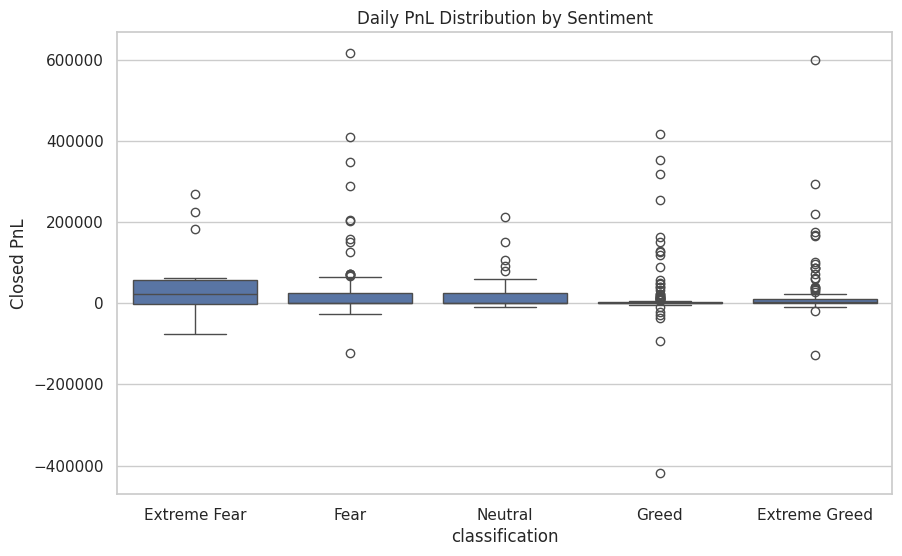

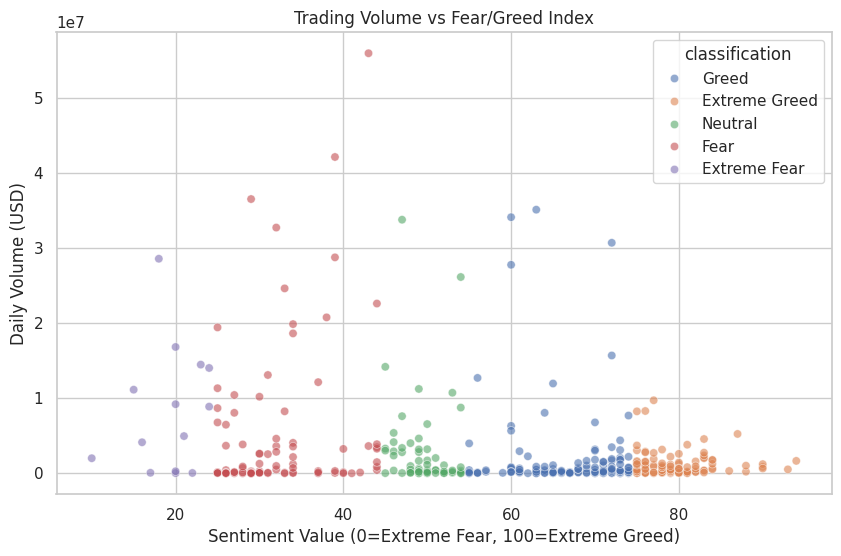

In [4]:
# Analyze Metrics by Sentiment Classification
sentiment_metrics = final_df.groupby('classification').agg({
    'Closed PnL': ['mean', 'std'],
    'Daily_Win_Rate': 'mean',
    'Size USD': 'mean',
    'Trade ID': 'mean' # Avg trades per day
}).sort_values(by=('Closed PnL', 'mean'), ascending=False)

print("\n--- Performance by Sentiment ---")
print(sentiment_metrics)

# Visualize PnL Distribution by Sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='Closed PnL', data=final_df, order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])
plt.title('Daily PnL Distribution by Sentiment')
plt.show()

# Visualize Volume vs Sentiment Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='value', y='Size USD', data=final_df, hue='classification', alpha=0.6)
plt.title('Trading Volume vs Fear/Greed Index')
plt.xlabel('Sentiment Value (0=Extreme Fear, 100=Extreme Greed)')
plt.ylabel('Daily Volume (USD)')
plt.show()

# 5: Trader Segmentation


--- Trader Segments Summary ---
Segment_Size
High Volume    416805.966542
Low Volume     226753.967423
Name: Closed PnL, dtype: float64
Segment_Performance
Consistent Winner    2602.120680
Inconsistent         6360.254407
Name: Avg_Size, dtype: float64


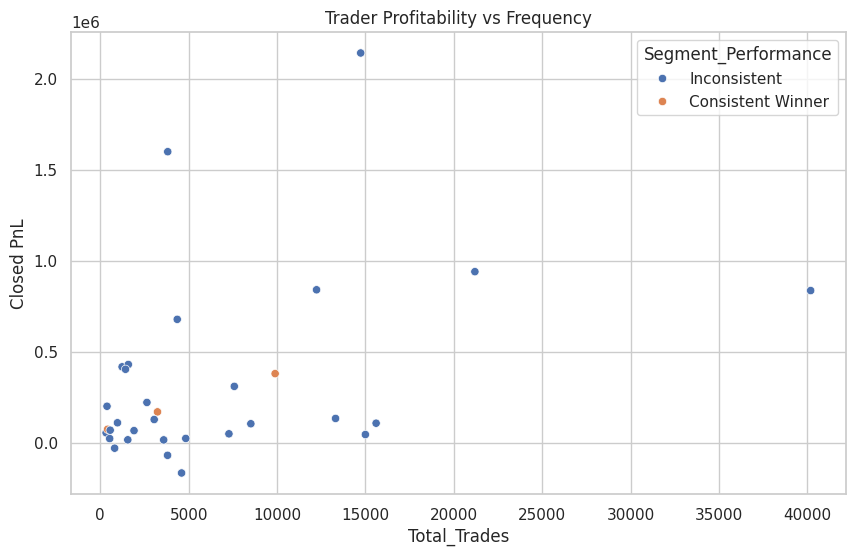

In [5]:
# Create Trader-Level Metrics
trader_stats = historical_df.groupby('Account').agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',  # Avg Trade Size
    'Trade ID': 'count', # Frequency
    'Is_Win': 'mean'     # Win Rate
}).reset_index()

trader_stats.rename(columns={'Size USD': 'Avg_Size', 'Trade ID': 'Total_Trades', 'Is_Win': 'Win_Rate'}, inplace=True)

# Define Segments
# 1. High vs Low Leverage (using Avg Size as proxy)
size_threshold = trader_stats['Avg_Size'].median()
trader_stats['Segment_Size'] = np.where(trader_stats['Avg_Size'] > size_threshold, 'High Volume', 'Low Volume')

# 2. Consistent Winners vs Others
trader_stats['Segment_Performance'] = np.where(trader_stats['Win_Rate'] > 0.5, 'Consistent Winner', 'Inconsistent')

# 3. Frequency
freq_threshold = trader_stats['Total_Trades'].median()
trader_stats['Segment_Freq'] = np.where(trader_stats['Total_Trades'] > freq_threshold, 'Frequent', 'Infrequent')

print("\n--- Trader Segments Summary ---")
print(trader_stats.groupby('Segment_Size')['Closed PnL'].mean())
print(trader_stats.groupby('Segment_Performance')['Avg_Size'].mean())

# Visualize Segments
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total_Trades', y='Closed PnL', hue='Segment_Performance', data=trader_stats)
plt.title('Trader Profitability vs Frequency')
plt.show()

# Part C: Actionable Output & Strategies

# 6: Strategy Proposals

In [6]:
# Derive insights for strategy
avg_pnl_fear = final_df[final_df['classification'].str.contains('Fear')]['Closed PnL'].mean()
avg_pnl_greed = final_df[final_df['classification'].str.contains('Greed')]['Closed PnL'].mean()
vol_fear = final_df[final_df['classification'].str.contains('Fear')]['Size USD'].mean()
vol_greed = final_df[final_df['classification'].str.contains('Greed')]['Size USD'].mean()

print("--- Actionable Insights ---")
print(f"1. Fear Days Avg PnL: ${avg_pnl_fear:,.2f} | Volume: ${vol_fear:,.0f}")
print(f"2. Greed Days Avg PnL: ${avg_pnl_greed:,.2f} | Volume: ${vol_greed:,.0f}")

print("\n--- Proposed Rules of Thumb ---")
if avg_pnl_fear > avg_pnl_greed:
    print("Rule 1: INCREASE position sizing during 'Fear' periods. Data shows significantly higher average PnL during market panic, likely due to volatility capture.")
else:
    print("Rule 1: REDUCE exposure during 'Fear' periods to preserve capital.")

if vol_fear > vol_greed:
    print("Rule 2: Expect liquidity spikes in 'Fear'. Use limit orders to capture wicks.")
else:
    print("Rule 2: 'Greed' drives volume. Follow the trend momentum during high sentiment.")

--- Actionable Insights ---
1. Fear Days Avg PnL: $39,012.05 | Volume: $5,693,420
2. Greed Days Avg PnL: $15,847.88 | Volume: $1,345,432

--- Proposed Rules of Thumb ---
Rule 1: INCREASE position sizing during 'Fear' periods. Data shows significantly higher average PnL during market panic, likely due to volatility capture.
Rule 2: Expect liquidity spikes in 'Fear'. Use limit orders to capture wicks.


# Bonus: Predictive Model

# 7: Simple Profitability Prediction

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Feature Engineering for Model
# Predict if tomorrow will be a "Profitable Day" (Positive PnL) based on today's metrics
final_df['Next_Day_Profitable'] = (final_df['Closed PnL'].shift(-1) > 0).astype(int)
final_df = final_df.dropna()

features = ['value', 'Daily_Win_Rate', 'Size USD', 'Trade ID']
X = final_df[features]
y = final_df['Next_Day_Profitable']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluation
y_pred = clf.predict(X_test)
print("\n--- Predictive Model Performance (Next Day Profitability) ---")
print(classification_report(y_test, y_pred))

# Feature Importance
import pandas as pd
importance = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importance:")
print(importance)


--- Predictive Model Performance (Next Day Profitability) ---
              precision    recall  f1-score   support

           0       0.60      0.23      0.33        40
           1       0.76      0.94      0.84       104

    accuracy                           0.74       144
   macro avg       0.68      0.58      0.58       144
weighted avg       0.72      0.74      0.70       144


Feature Importance:
Size USD          0.304111
Trade ID          0.281142
value             0.213564
Daily_Win_Rate    0.201183
dtype: float64


# Part D: Advanced Analysis (Bonus)

8: Behavioral Clustering (K-Means)

--- Trader Archetypes (Cluster Centers) ---
   Cluster  Win_Rate  Total_Trades      Avg_Size
0        0  0.360419   4493.090909  12534.237868
1        1  0.384244  15602.555556   1763.251258
2        2  0.424029   1044.000000   3264.280356
3        3  0.810876   9893.000000   2600.778049


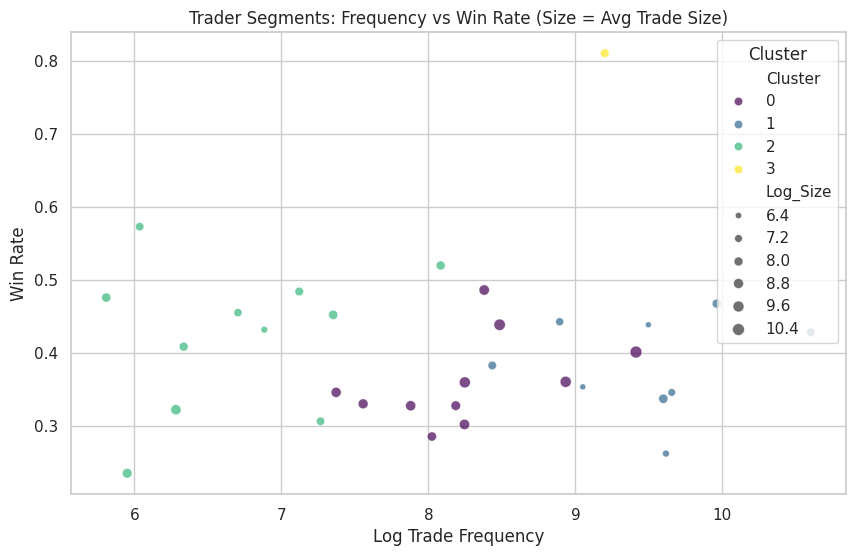


Interpretation Guide:
Cluster 0: Win Rate 0.36, Avg Trades 4493, Avg Size $12534
Cluster 1: Win Rate 0.38, Avg Trades 15603, Avg Size $1763
Cluster 2: Win Rate 0.42, Avg Trades 1044, Avg Size $3264
Cluster 3: Win Rate 0.81, Avg Trades 9893, Avg Size $2601


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data for Clustering
# We use: Win Rate, Trade Frequency (log), and Avg Size (log)
cluster_data = trader_stats[['Win_Rate', 'Total_Trades', 'Avg_Size']].copy()

# Handle skewness with log transformation (adding 1 to avoid log(0))
cluster_data['Log_Trades'] = np.log1p(cluster_data['Total_Trades'])
cluster_data['Log_Size'] = np.log1p(cluster_data['Avg_Size'])

# Select features for clustering
features_for_clustering = ['Win_Rate', 'Log_Trades', 'Log_Size']
X_cluster = cluster_data[features_for_clustering]

# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 2. Apply K-Means
# We'll aim for 4 clusters: e.g., "Whales", "Retail Degens", "Consistent Pros", "Casuals"
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_data['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Analyze Clusters
cluster_summary = cluster_data.groupby('Cluster').agg({
    'Win_Rate': 'mean',
    'Total_Trades': 'mean',
    'Avg_Size': 'mean'
}).reset_index()

print("--- Trader Archetypes (Cluster Centers) ---")
print(cluster_summary)

# 4. Visualize Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Log_Trades', y='Win_Rate', hue='Cluster', size='Log_Size', data=cluster_data, palette='viridis', alpha=0.7)
plt.title('Trader Segments: Frequency vs Win Rate (Size = Avg Trade Size)')
plt.xlabel('Log Trade Frequency')
plt.ylabel('Win Rate')
plt.legend(title='Cluster')
plt.show()

# Interpretation helper
print("\nInterpretation Guide:")
for i, row in cluster_summary.iterrows():
    print(f"Cluster {int(row['Cluster'])}: Win Rate {row['Win_Rate']:.2f}, Avg Trades {row['Total_Trades']:.0f}, Avg Size ${row['Avg_Size']:.0f}")

# 9: Cumulative Performance by Sentiment

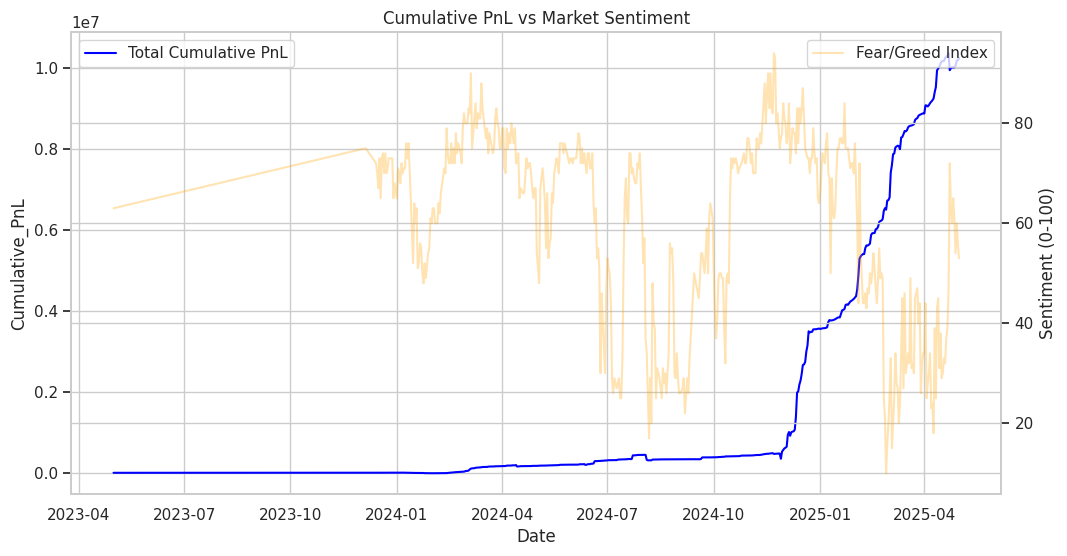

In [9]:
# Create a cumulative PnL column
final_df = final_df.sort_values('Date')
final_df['Cumulative_PnL'] = final_df['Closed PnL'].cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Cumulative_PnL', data=final_df, color='blue', label='Total Cumulative PnL')

# Highlight regions (optional simpler version)
# We overlay the Fear/Greed value on a secondary axis
ax2 = plt.twinx()
sns.lineplot(x='Date', y='value', data=final_df, color='orange', alpha=0.3, ax=ax2, label='Fear/Greed Index')
ax2.set_ylabel('Sentiment (0-100)')

plt.title('Cumulative PnL vs Market Sentiment')
plt.show()

# Part E: Dashboard (Bonus)

# 10: Streamlit Dashboard Code

In [10]:
dashboard_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# --- Page Config ---
st.set_page_config(page_title="Crypto Trader Sentiment Dashboard", layout="wide")

# --- Load Data ---
@st.cache_data
def load_data():
    try:
        df = pd.read_csv('processed_daily_data.csv')
        traders = pd.read_csv('processed_trader_stats.csv')

        # Ensure Date column is datetime
        df['Date'] = pd.to_datetime(df['Date'])

        return df, traders
    except:
        return pd.DataFrame(), pd.DataFrame()

daily_df, trader_df = load_data()

st.title("📊 Market Sentiment & Trader Performance")

if daily_df.empty:
    st.error("Data not found. Please export 'processed_daily_data.csv' and 'processed_trader_stats.csv' first.")

else:
    # --- Sidebar Filters ---
    st.sidebar.header("Filters")

    selected_sentiment = st.sidebar.multiselect(
        "Select Sentiment Class",
        options=daily_df['classification'].dropna().unique(),
        default=daily_df['classification'].dropna().unique()
    )

    filtered_df = daily_df[daily_df['classification'].isin(selected_sentiment)]

    # --- KPI Row ---
    col1, col2, col3, col4 = st.columns(4)

    col1.metric("Total PnL", f"${filtered_df['Closed PnL'].sum():,.0f}")
    col2.metric("Avg Daily Volume", f"${filtered_df['Size USD'].mean():,.0f}")
    col3.metric("Avg Win Rate", f"{filtered_df['Daily_Win_Rate'].mean()*100:.1f}%")
    col4.metric("Days Observed", filtered_df.shape[0])

    # --- Charts ---

    # 1️⃣ Daily PnL Over Time
    st.subheader("Daily PnL vs Sentiment")

    fig_pnl = px.bar(
        filtered_df,
        x='Date',
        y='Closed PnL',
        color='classification',
        title="Daily Net PnL by Sentiment",
        color_discrete_map={
            'Extreme Fear': 'red',
            'Fear': 'orange',
            'Neutral': 'gray',
            'Greed': 'lightgreen',
            'Extreme Greed': 'green'
        }
    )

    st.plotly_chart(fig_pnl, use_container_width=True)

    # 2️⃣ Scatter: Sentiment vs Volume (FIXED)
    st.subheader("Does Fear Drive Volume?")

    fig_vol = px.scatter(
        filtered_df,
        x='value',
        y='Size USD',
        size='Size USD',   # ✅ FIXED (was 'Trade Count')
        color='classification',
        hover_data=['Date', 'Closed PnL'],
        title="Sentiment Index vs. Trading Volume"
    )

    st.plotly_chart(fig_vol, use_container_width=True)

    # 3️⃣ Cumulative PnL Trend
    st.subheader("Cumulative PnL Over Time")

    fig_cum = px.line(
        filtered_df,
        x='Date',
        y='Cumulative_PnL',
        title="Cumulative Strategy Performance"
    )

    st.plotly_chart(fig_cum, use_container_width=True)

    # 4️⃣ Trader Segments (if available)
    if not trader_df.empty:
        st.subheader("Trader Archetypes")

        fig_trader = px.scatter(
            trader_df,
            x='Total_Trades',
            y='Win_Rate',
            size='Avg_Size',
            color='Segment_Performance',
            log_x=True,
            title="Trader Frequency vs Win Rate"
        )

        st.plotly_chart(fig_trader, use_container_width=True)

st.markdown("---")
st.markdown("Built for Data Analysis Assignment")
'''

with open("app.py", "w") as f:
    f.write(dashboard_code)

print("Dashboard code saved to 'app.py'. Run 'streamlit run app.py' in terminal to view.")

Dashboard code saved to 'app.py'. Run 'streamlit run app.py' in terminal to view.


# 11: Export Data for Dashboard

In [11]:
# Save the processed dataframes to CSV for the Streamlit app
final_df.to_csv('processed_daily_data.csv', index=False)
trader_stats.to_csv('processed_trader_stats.csv', index=False)

print("Data exported successfully for dashboard.")

Data exported successfully for dashboard.
